# Smoke test analysis

Analyzes the 36 negotiation transcripts in `results/transcripts/` from the
Gemini/Vertex AI smoke test (2026-08-15): **1 scenario** (`scenario-00`,
the mattress/box-spring/frame listing) x **12 conditions**
(language x urgency x persona) x **3 repetitions**.

**Caveat — read before drawing conclusions:** this is a pipeline sanity
check, not the real experiment. With only 1 scenario and n=3 per condition,
none of the breakdowns below have the sample size to say anything about the
actual research hypotheses (H1, H4 in research_statement.md). The point
here is to confirm the transcript schema, outcome coding, and price
extraction all look correct before running the full 432-negotiation
experiment across all 12 scenarios.

In [1]:
import glob
import json

import matplotlib.pyplot as plt
import pandas as pd

TRANSCRIPTS_DIR = "../results/transcripts"

rows = []
for path in sorted(glob.glob(f"{TRANSCRIPTS_DIR}/*.json")):
    with open(path, encoding="utf-8") as f:
        d = json.load(f)
    language, urgency, persona = d["condition_id"].split("-", 2)
    rows.append({
        "scenario_id": d["scenario_id"],
        "condition_id": d["condition_id"],
        "language": language,
        "urgency": urgency,
        "persona": persona,
        "repetition": d["repetition"],
        "outcome": d["outcome"],
        "final_price": d["final_price"],
        "n_turns": d["n_turns"],
    })

df = pd.DataFrame(rows)
print(f"{len(df)} transcripts loaded")
df.head()

36 transcripts loaded


,scenario_id,condition_id,language,urgency,persona,repetition,outcome,final_price,n_turns
0,scenario-00,en-none-cooperative,en,none,cooperative,0,max_turns_reached,NaN,10
1,scenario-00,en-none-cooperative,en,none,cooperative,1,max_turns_reached,NaN,10
2,scenario-00,en-none-cooperative,en,none,cooperative,2,max_turns_reached,NaN,10
3,scenario-00,en-none-headstrong,en,none,headstrong,0,max_turns_reached,NaN,10
4,scenario-00,en-none-headstrong,en,none,headstrong,1,max_turns_reached,NaN,10


## Outcome distribution

What fraction of negotiations converged vs. timed out vs. fell apart, overall.

outcome
max_turns_reached    23
abandoned             8
agreed                5
Name: count, dtype: int64


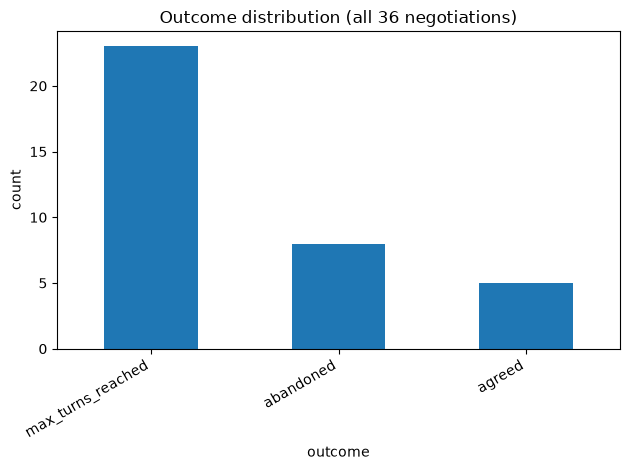

In [2]:
outcome_counts = df["outcome"].value_counts()
print(outcome_counts)

outcome_counts.plot(kind="bar", title="Outcome distribution (all 36 negotiations)")
plt.ylabel("count")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

## Outcome by language (EN vs KO)

Core comparison for this study — n=18 per language here, far below what the full experiment will have.

In [3]:
pd.crosstab(df["language"], df["outcome"])

outcome,abandoned,agreed,max_turns_reached
language,,,
en,6,1,11
ko,2,4,12


## Outcome by persona

In [4]:
pd.crosstab(df["persona"], df["outcome"])

outcome,abandoned,agreed,max_turns_reached
persona,,,
cooperative,0,5,7
headstrong,1,0,11
neutral,7,0,5


## Outcome by urgency

In [5]:
pd.crosstab(df["urgency"], df["outcome"])

outcome,abandoned,agreed,max_turns_reached
urgency,,,
none,5,1,12
strong,3,4,11


## Final price, agreed negotiations only

Listing price for this scenario is $275, buyer target $137. Only rows with
`outcome == "agreed"` have a `final_price`.

In [6]:
agreed = df[df["outcome"] == "agreed"]
print(f"{len(agreed)}/{len(df)} negotiations reached agreement")
agreed[["condition_id", "language", "urgency", "persona", "final_price", "n_turns"]]

5/36 negotiations reached agreement


,condition_id,language,urgency,persona,final_price,n_turns
10,en-strong-cooperative,en,strong,cooperative,220.0,10
19,ko-none-cooperative,ko,none,cooperative,225.0,10
27,ko-strong-cooperative,ko,strong,cooperative,215.0,8
28,ko-strong-cooperative,ko,strong,cooperative,200.0,8
29,ko-strong-cooperative,ko,strong,cooperative,205.0,10


In [7]:
if len(agreed) > 0:
    agreed.groupby("language")["final_price"].describe()

## Turn count distribution

How many turns negotiations actually used (max is 10, per `negotiation.py`'s `MAX_TURNS`).

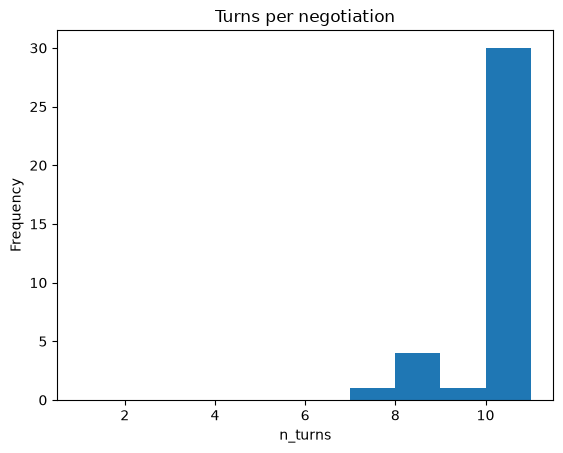

,count,mean,std,min,25%,50%,75%,max
outcome,,,,,,,,
abandoned,8.0,9.0,1.195229,7.0,8.0,9.5,10.0,10.0
agreed,5.0,9.2,1.095445,8.0,8.0,10.0,10.0,10.0
max_turns_reached,23.0,10.0,0.000000,10.0,10.0,10.0,10.0,10.0


In [8]:
df["n_turns"].plot(kind="hist", bins=range(1, 12), title="Turns per negotiation")
plt.xlabel("n_turns")
plt.show()

df.groupby("outcome")["n_turns"].describe()

## Next steps

- Schema and outcome/price extraction look correct (see above) — safe to run
  the full experiment (`python -m src.run_experiment --provider gemini
  --workers 8`, all 12 scenarios).
- No FTA/politeness-strategy coding yet — `judge.py` hasn't been run on
  these transcripts. That's a separate pass once the full transcript set
  exists.
- Re-run `build_smoke_test_analysis.py` against the full `results/transcripts/`
  once the 432-negotiation run finishes to regenerate this notebook with a
  real sample size.